## Disciplina VIS101: Fundamentos em Visão Computacional



In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

print('Setup pronto.')

Setup pronto.


### A imagem em tons de cinza

A intensidade da imagem é estudada a partir de tons de cinza, de forma que cada pixel guarda um único valor, a sua intensidade luminosa.

In [2]:
img = cv2.imread('../images/cat.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f'Dimensões da imagem: {gray.shape} \nTipo de dado: {gray.dtype}')


Dimensões da imagem: (900, 1600) 
Tipo de dado: uint8


A imagem 'gray' criada é uma imagem em tons de cinza composta por inteiros de 8 bits e pode ser visualizada abaixo.

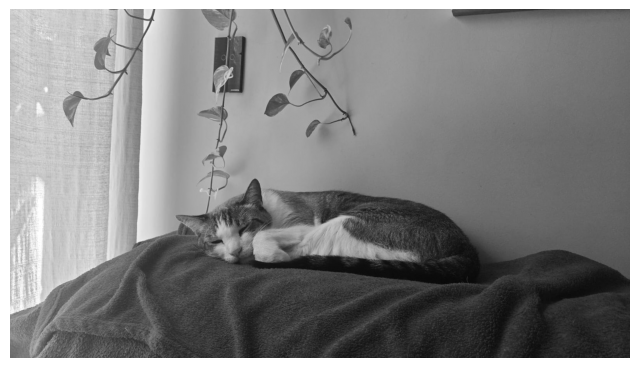

In [3]:
plt.imshow(gray, cmap='gray', vmin = 0, vmax = 255)
plt.axis('off')
plt.show()

## O histograma

O histograma conta, para cada nível de intensidade $k$, quantos pixels têm aquele valor:

$$h(k) = \#\{(x, y) : f(x, y) = k\}$$

É o raio-X da imagem: revela se ela é escura, clara, de alto ou baixo contraste antes mesmo de olharmos para ela.

Na imagem analisada aqui (uint8), esse nível $k$ varia de 0 (preto absoluto) a 255 (branco absoluto).


In [4]:
# Calcula o histograma (imagem gray, canal 0, sem máscara (None), 256 bins (fatias/barras), tons de 0 a 255)
hist = cv2.calcHist([gray], [0], None, [256], [0, 256]) 

print(f'Soma do histograma: {int(hist.sum())} \nTotal de pixels: {gray.size}')

Soma do histograma: 1440000 
Total de pixels: 1440000


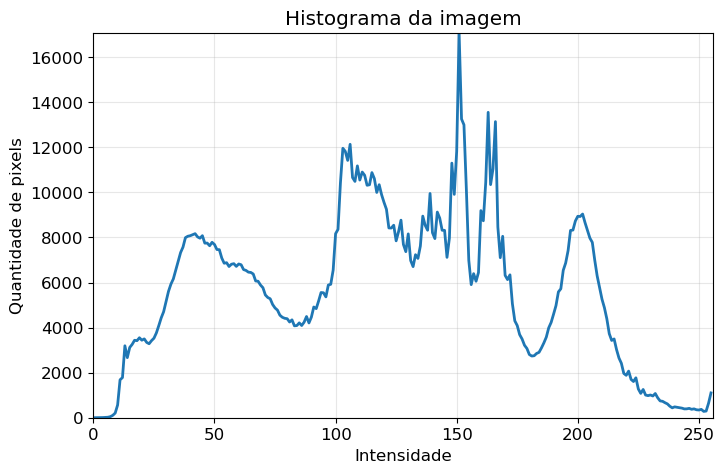

In [5]:
plt.plot(hist)
plt.xlim([0, 256])
plt.ylim([0, hist.max()])
plt.title('Histograma da imagem')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')
plt.show()


A área total sob a curva do histograma equivale ao número total de pixels da imagem. No histograma, os picos revelam os tons predominantes na imagem, enquanto os vales indicam as faixas de intensidade raras ou ausentes.

### O Histograma como ferramenta de diagnóstico

O formato da curva funciona como um exame rápido da imagem. Ele revela, de imediato, a qualidade tonal da foto.

Uma imagem subexposta (muito escura) acumula seus pixels no lado esquerdo do gráfico, enquanto uma superexposta (muito clara) concentra os picos à direita.

Uma imagem de baixo contraste apresenta um histograma "espremido" em uma faixa estreita, ignorando os extremos de preto e branco. 

#### Para visualizar esses cenários na prática, geraremos a seguir três versões distorcidas a partir da imagem original.

In [6]:
escura = np.clip(gray * 0.4, 0, 255).astype(np.uint8)       # Escurece reduzindo a intensidade para 40%, trava em 0-255 e devolve para uint8
clara = np.clip(gray * 0.6 + 120, 0, 255).astype(np.uint8)  # Reduz o contraste (60%) para não perder detalhes e soma 120 para clarear tudo
baixo = np.clip(gray * 0.35 + 90, 0, 255).astype(np.uint8)  # "Achata" o contraste a 35% e empurra os tons para o meio do gráfico (+90)
casos = [('original', gray), ('escura', escura), ('clara', clara), ('baixo contraste', baixo)] # Agrupa rótulos e imagens em uma lista para facilitar a plotagem

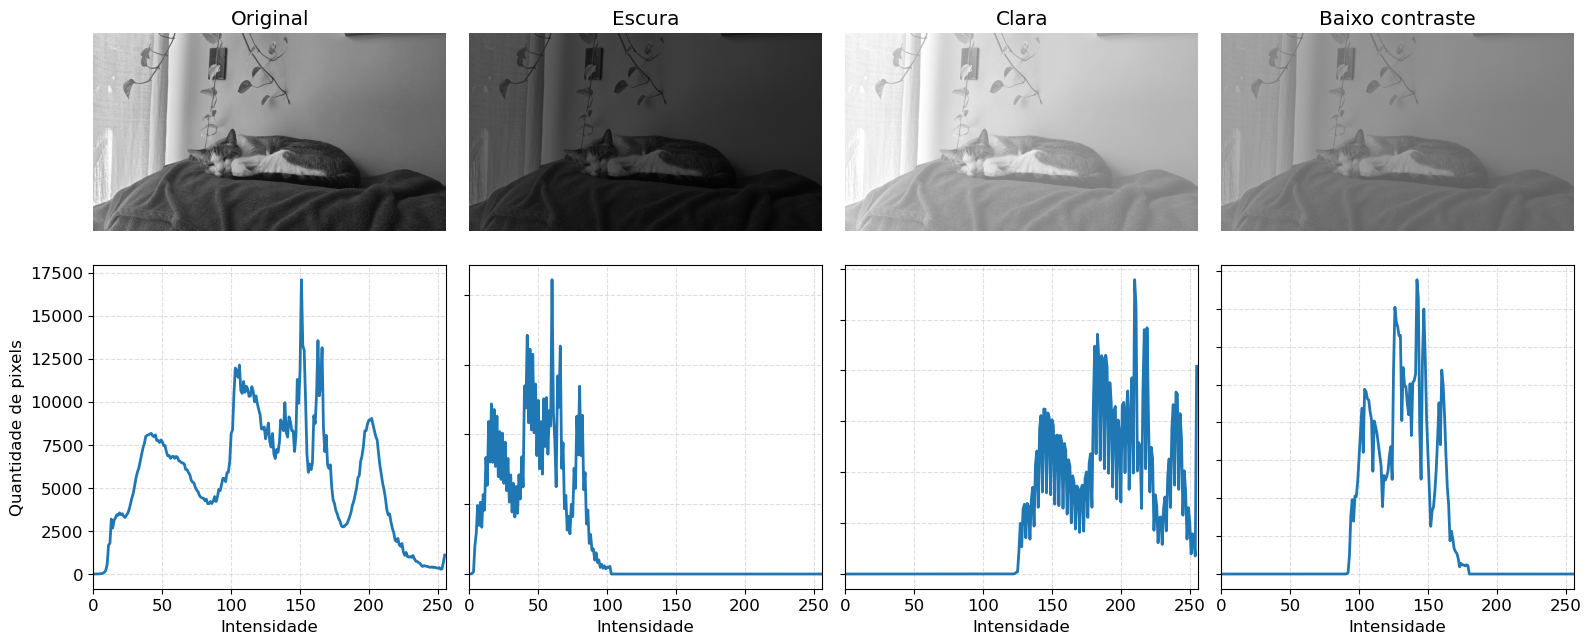

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, (nome, im) in enumerate(casos):
    
    # Plotagem das imagens
    ax_img = axes[0, i]
    ax_img.imshow(im, cmap='gray', vmin=0, vmax=255)
    
    # Capitaliza a primeira letra do título para ficar mais elegante
    ax_img.set_title(nome.capitalize())
    ax_img.axis('off')
    
    # Plotagem dos histogramas
    ax_hist = axes[1, i]
    hist = cv2.calcHist([im], [0], None, [256], [0, 256])
    
    # Traça a linha do gráfico
    ax_hist.plot(hist)
        
    ax_hist.set_xlim([0, 256])
    ax_hist.set_xlabel('Intensidade')
    
    # Para evitar poluição visual, deixamos o eixo Y (Quantidade de pixels) apenas no primeiro gráfico
    if i == 0:
        ax_hist.set_ylabel('Quantidade de pixels')
    else:
        ax_hist.set_yticklabels([]) # Apaga os números do eixo Y das colunas 2, 3 e 4
        
    ax_hist.grid(True, linestyle='--', alpha=0.4)

# Ajusta automaticamente as margens para que os gráficos não se sobreponham
plt.tight_layout()
plt.show()

A análise visual confirma: o formato da curva conta a história da imagem. Na versão escura, a massa de pixels é deslocada para a extrema esquerda (tons escuros). Na versão clara, eles se concentram à direita (tons claros). Já na imagem de baixo contraste, toda a informação fica achatada e restrita ao centro do gráfico.

### Transformações de intensidade

Uma transformação de intensidade remapeia cada valor de pixel por uma função:

$$s = T(r)$$

onde $r$ é a intensidade de entrada e $s$ a de saída. É uma operação pontual: o novo valor de um pixel depende apenas do valor antigo dele, não dos vizinhos.

É uma operação pontual: o novo valor de um pixel depende apenas do valor antigo dele, não dos vizinhos. Na prática, foi exatamente isso que fizemos no passo anterior: aplicamos funções matemáticas simples (multiplicação e soma) para transformar os pixels originais $r$ e gerar os novos pixels $s$ das versões claras e escuras.

### Ajuste de Brilho

Aumentar o brilho de uma imagem significa somar uma constante $b$ a todos os seus pixels, deslocando a curva do histograma inteira para a direita. A função matemática é simples: 

$$s = r + b$$

> **Nota:** O uso do `clip` garante que a soma não ultrapasse o limite de 255.

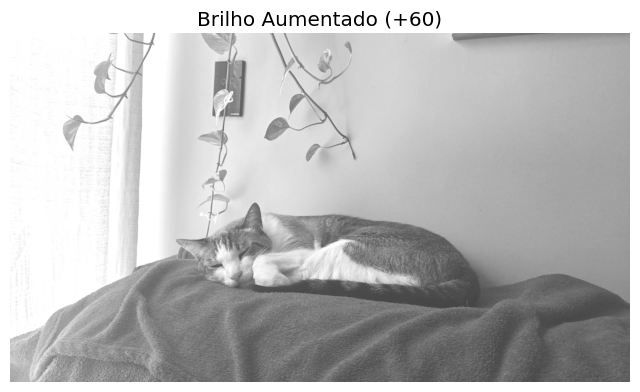

In [8]:
# Converte para int (evitando overflow), soma 60 de brilho, trava em 255 e devolve para uint8
brilho = np.clip(gray.astype(int) + 60, 0, 255).astype(np.uint8)

# Plotagem da imagem clareada
plt.imshow(brilho, cmap = 'gray', vmin = 0, vmax = 255)
plt.title('Brilho Aumentado (+60)')
plt.axis('off')
plt.show()

### Ajuste de Contraste

Multiplicar os pixels por um fator $\alpha$ maior que 1 aumenta a distância entre os tons, "esticando" o histograma para afastar as intensidades umas das outras. A função matemática é:

$$s = \alpha \cdot r$$

> **Nota:** Ao multiplicar por um valor decimal (como 1,6), o NumPy converte os valores temporariamente para ponto flutuante (`float`), evitando erros de memória. O `clip` garante que nenhum valor ultrapasse 255.


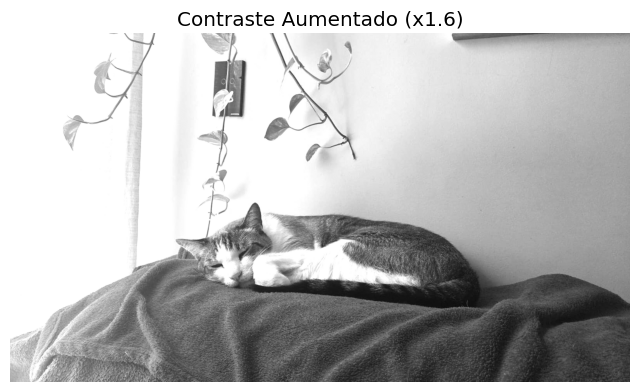

In [9]:
# Multiplica por 1.6 (esticando o contraste), trava o teto em 255 e devolve para uint8
contraste = np.clip(1.6 * gray, 0, 255).astype(np.uint8)

# Plotagem da imagem com alto contraste
plt.imshow(contraste, cmap = 'gray', vmin = 0, vmax = 255)
plt.title('Contraste Aumentado (x1.6)')
plt.axis('off')
plt.show()

### Negativo

Inverter a intensidade produz o efeito de negativo fotográfico. Essa técnica é extremamente útil para realçar detalhes claros que estão escondidos em regiões extensas e escuras, como na análise de radiografias e exames médicos. A função matemática é:

$$s = 255 - r$$

> **Nota:** Diferente do brilho e do contraste, aqui não precisamos da função `clip`. Como a intensidade original $r$ sempre varia de 0 a 255, a subtração garante matematicamente que o novo valor $s$ nunca ultrapassará esses mesmos limites.

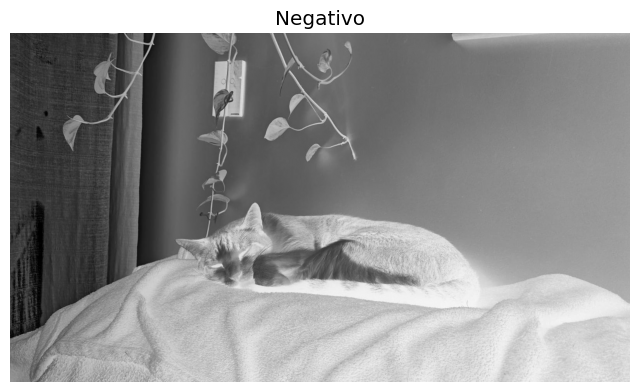

In [10]:
# Inverte os pixels: o que era 255 (branco) vira 0 (preto) e vice-versa
negativo = 255 - gray

# Plotagem da imagem invertida
plt.imshow(negativo, cmap = 'gray', vmin = 0, vmax = 255)
plt.title('Negativo')
plt.axis('off')
plt.show()

### Correção Gama

A correção gama é uma transformação não linear:

$$s = c \left(\frac{r}{255}\right)^{\gamma} \cdot 255$$

Com $\gamma < 1$, as sombras clareiam; com $\gamma > 1$, elas escurecem. Essa é a curva matemática que descreve como monitores, telas e câmeras codificam e exibem a luminância de forma mais próxima à percepção do olho humano.

> **Nota:** Diferente das transformações lineares (soma e multiplicação simples), a potenciação exige que os pixels sejam normalizados para uma escala de 0 a 1 (dividindo por `255.0`) antes da operação. Após a aplicação do expoente gama, multiplicamos por 255 para retornar à escala original.

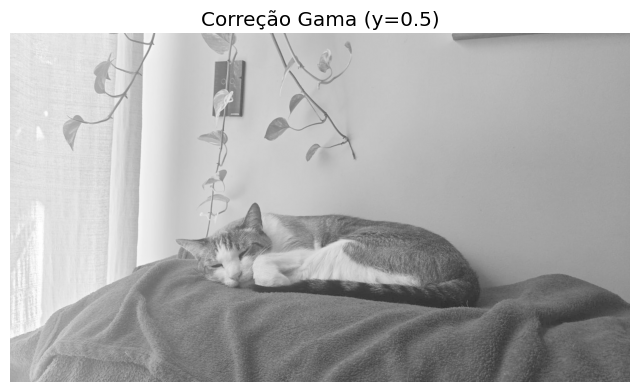

In [11]:
# Define o valor de gama (menor que 1 clareia a imagem, expandindo as sombras)
gamma = 0.5

# Normaliza (0.0 a 1.0), aplica a potência gama, escala de volta e converte para uint8
pot = np.clip(((gray / 255.0) ** gamma) * 255, 0, 255).astype(np.uint8)

# Plotagem da imagem com correção gama
plt.imshow(pot, cmap='gray', vmin=0, vmax=255)
plt.title(f'Correção Gama (y={gamma})')
plt.axis('off')
plt.show()

**Exemplo com $\gamma > 1$ (escurecimento):**

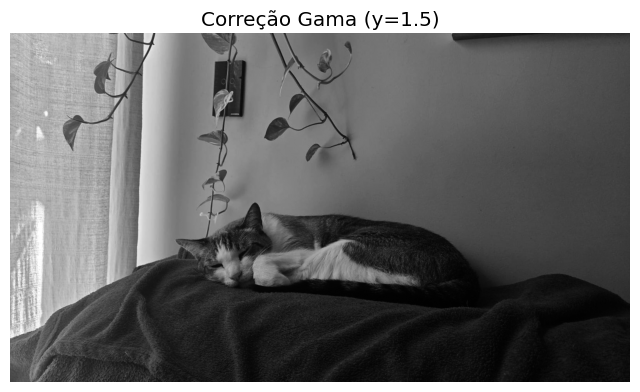

In [12]:
# Define o valor de gama (maior que 1 escurece a imagem, comprimindo os tons claros)
gamma = 1.5

# Normaliza (0.0 a 1.0), aplica a potência gama, escala de volta e converte para uint8
pot = np.clip(((gray / 255.0) ** gamma) * 255, 0, 255).astype(np.uint8)

# Plotagem da imagem com correção gama
plt.imshow(pot, cmap='gray', vmin=0, vmax=255)
plt.title(f'Correção Gama (y={gamma})')
plt.axis('off')
plt.show()

### Transformação Logarítmica

O logaritmo comprime as intensidades altas e expande as intensidades baixas. Essa característica o torna a ferramenta ideal para realçar detalhes sutis que estão escondidos nas partes escuras da imagem, sem o risco de "estourar" (superexpor) as áreas que já são claras. A função matemática é:

$$s = c \cdot \log(1 + r)$$

> **Nota:** O $1$ somado a $r$ impede que a função tente calcular o $\log(0)$ em pixels totalmente pretos (o que geraria um erro). A constante $c$ é calculada de forma dinâmica para garantir que o valor máximo da nova imagem seja exatamente 255, aproveitando todo o alcance tonal.

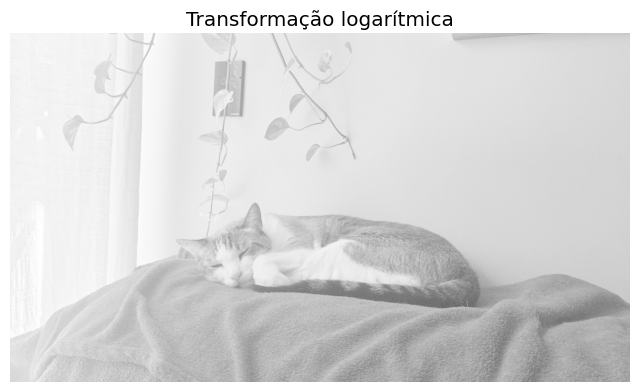

In [13]:
# O uso de '1.0' (float) evita o overflow na soma caso o max() seja 255, calculando a constante de escala 'c'
c = 255 / np.log(1.0 + gray.max())

# Converte para float, soma 1.0 (evitando log(0)), aplica a escala 'c', corta no teto e devolve a uint8
log = np.clip(c * np.log(1.0 + gray.astype(float)), 0, 255).astype(np.uint8)

# Plotagem da imagem com transformação logarítmica
plt.imshow(log, cmap='gray', vmin=0, vmax=255)
plt.title('Transformação logarítmica')
plt.axis('off')
plt.show()

## Equalização de Histograma

As transformações anteriores utilizam curvas matemáticas fixas. A **equalização** vai um passo além: ela calcula a curva de transformação automaticamente a partir da distribuição estatística da própria imagem. O objetivo é redistribuir as intensidades para que ocupem toda a faixa disponível (de 0 a 255) de forma mais uniforme. É o remédio clássico para imagens de baixo contraste.

Para ver isso na prática, aplicamos a função sobre a versão de baixo contraste que geramos anteriormente:

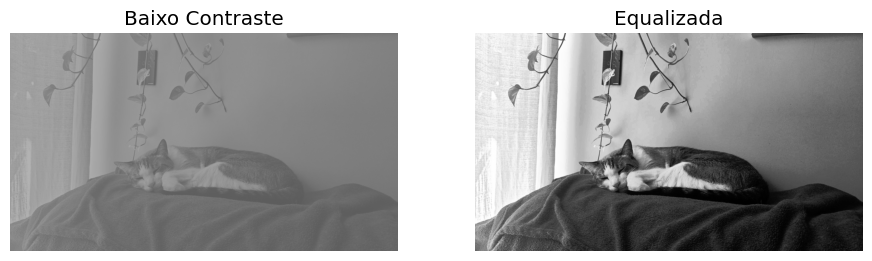

In [14]:
# Analisa a imagem e redistribui as intensidades automaticamente
eq = cv2.equalizeHist(baixo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(baixo, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Baixo Contraste')
axes[0].axis('off')

axes[1].imshow(eq, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Equalizada')
axes[1].axis('off')

plt.show()

Para comprovar o efeito visualmente, plotamos os histogramas das duas imagens. Note como o gráfico "Antes" possui toda a informação espremida no centro, enquanto o "Depois" mostra como o algoritmo esticou e redistribuiu esses dados de ponta a ponta na escala de 0 a 255.

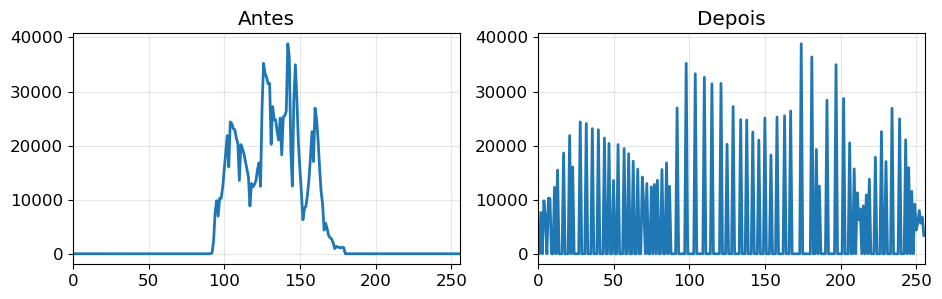

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(cv2.calcHist([baixo], [0], None, [256], [0, 256])); axes[0].set_xlim([0, 256]); axes[0].set_title('Antes')
axes[1].plot(cv2.calcHist([eq], [0], None, [256], [0, 256])); axes[1].set_xlim([0, 256]); axes[1].set_title('Depois')
plt.show()

### Equalização adaptativa (CLAHE)

A equalização global aplica a mesma curva à imagem inteira, o que pode "estourar" ou criar ruídos indesejados em regiões muito amplas e homogêneas, como o céu em uma paisagem. 

Para resolver isso, utilizamos o **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*). Essa técnica divide a imagem em pequenos blocos locais (grades) e equaliza o histograma de cada bloco individualmente, além de aplicar um limite máximo para o ganho de contraste. O resultado é uma imagem muito mais natural e bem balanceada.

Aplicamos sobre a versão de baixo contraste para comparar com a equalização tradicional:

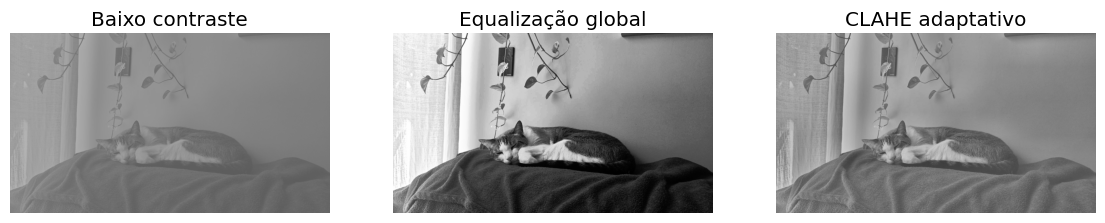

In [16]:
# Cria o objeto CLAHE
# clipLimit: Limiar de contraste (evita que o ruído ou fundos homogêneos estourem)
# tileGridSize: Divide a imagem em blocos locais (aqui, grades de 8x8 pixels)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Aplica o filtro na imagem de baixo contraste
cl = clahe.apply(baixo)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

imagens = [('Baixo contraste', baixo), ('Equalização global', eq), ('CLAHE adaptativo', cl)]

for ax, (nome, im) in zip(axes, imagens):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(nome)
    ax.axis('off')

plt.show()

### Equalização em imagens coloridas

Tentar equalizar os três canais (RGB) de uma imagem colorida separadamente causa distorções graves nas cores finais, pois altera a proporção entre elas. O caminho correto e seguro é converter a imagem para o espaço de cores **HSV** (Hue, Saturation, Value) e equalizar apenas o canal **V** (Value / Luminância). Dessa forma, melhoramos o contraste enquanto preservamos o matiz (a cor em si) e a saturação intactos.

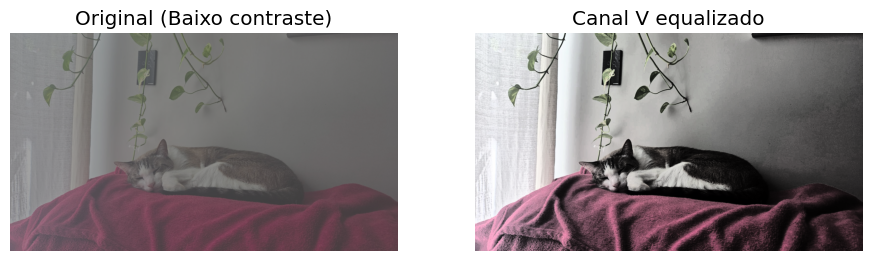

In [17]:
# Cria uma versão de baixo contraste da imagem colorida original
img_low = np.clip(img * 0.4 + 60, 0, 255).astype(np.uint8)

# Converte de BGR (padrão OpenCV) para HSV
hsv = cv2.cvtColor(img_low, cv2.COLOR_BGR2HSV)

# Separa a imagem em seus três canais independentes
h, s, v = cv2.split(hsv)

# Aplica a equalização de histograma apenas no canal V (Luminância)
v_eq = cv2.equalizeHist(v)

# Mescla os canais novamente (com o V ajustado) e reverte para o espaço BGR
img_eq = cv2.cvtColor(cv2.merge([h, s, v_eq]), cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plota a imagem original. O [:, :, ::-1] inverte rapidamente de BGR para RGB para o Matplotlib
axes[0].imshow(img_low[:, :, ::-1])
axes[0].set_title('Original (Baixo contraste)')
axes[0].axis('off')

# Plota a imagem após a equalização da luminância
axes[1].imshow(img_eq[:, :, ::-1])
axes[1].set_title('Canal V equalizado')
axes[1].axis('off')

plt.show()

Como visto, o espaço HSV cumpriu seu papel de blindar a identidade das cores (o matiz). No entanto, na prática, a equalização global (equalizeHist) força o contraste ao extremo. O resultado matemático é correto, mas o resultado visual é artificial e esteticamente desagradável, pois destrói a suavidade das sombras reais. É aqui que entra a necessidade de métodos adaptativos, como o CLAHE.

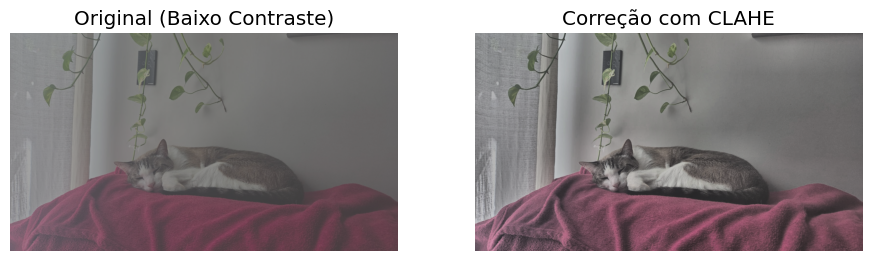

In [18]:
# Cria o objeto CLAHE com um limite suave
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Aplica o CLAHE APENAS no canal V (Luminância)
v_clahe = clahe.apply(v)

# Mescla os canais (h, s, v_clahe) e converte de volta para BGR
img_clahe = cv2.cvtColor(cv2.merge([h, s, v_clahe]), cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_low[:, :, ::-1])
axes[0].set_title('Original (Baixo Contraste)')
axes[0].axis('off')

axes[1].imshow(img_clahe[:, :, ::-1])
axes[1].set_title('Correção com CLAHE')
axes[1].axis('off')

plt.show()

A aplicação do CLAHE no canal V corrigiu perfeitamente o problema de iluminação (contraste). No entanto, como a degradação original afetou os canais RGB como um todo, a pureza das cores (Saturação) também havia sido perdida. Isso demonstra que equalizar a luminância não é suficiente se a saturação da imagem também estiver comprometida, resultando em um aspecto 'lavado'.

### Corrigindo a saturação

Como vimos, a imagem original perdeu tanto o contraste (iluminação) quanto a saturação (pureza das cores). Após corrigir a luminância (canal V) com o CLAHE, precisamos compensar a perda de cor no canal S.

Para isso, multiplicamos o canal de saturação por um fator (1.5) antes de mesclar a imagem novamente, devolvendo a "vida" à foto.


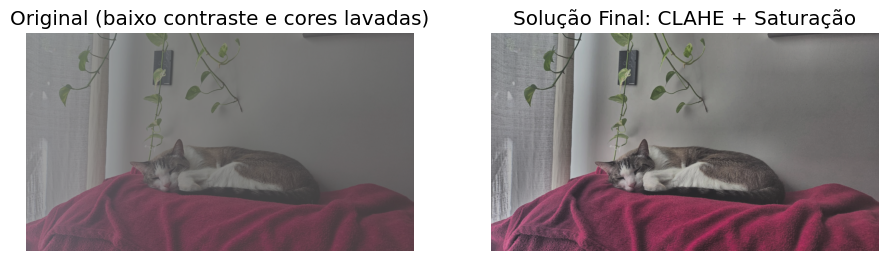

In [19]:
# Aplicamos o CLAHE no canal V (luminância) para corrigir o contraste da iluminação
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
v_clahe = clahe.apply(v)

# Multiplicamos a saturação por 1.5 para devolver a força das cores.
# O np.clip é essencial aqui para garantir que nenhuma cor passe do limite e estoure.
s_boost = np.clip(s * 1.5, 0, 255).astype(np.uint8)

# Mesclamos os canais: Matiz intacto (h), Saturação revivida (s_boost) e Luminância equalizada (v_clahe)
img_final = cv2.cvtColor(cv2.merge([h, s_boost, v_clahe]), cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(img_low[:, :, ::-1])
axes[0].set_title('Original (baixo contraste e cores lavadas)')
axes[0].axis('off')

axes[1].imshow(img_final[:, :, ::-1])
axes[1].set_title('Solução Final: CLAHE + Saturação')
axes[1].axis('off')

plt.show()

### Do histograma à decisão

Ler o histograma não é um fim em si: ele orienta escolhas. A aplicação mais direta dessa leitura é o **limiar de binarização** (thresholding), uma técnica que separa a imagem em apenas dois grupos (preto e branco absolutos) a partir de um valor de corte (limiar) escolhido com base na distribuição dos pixels.

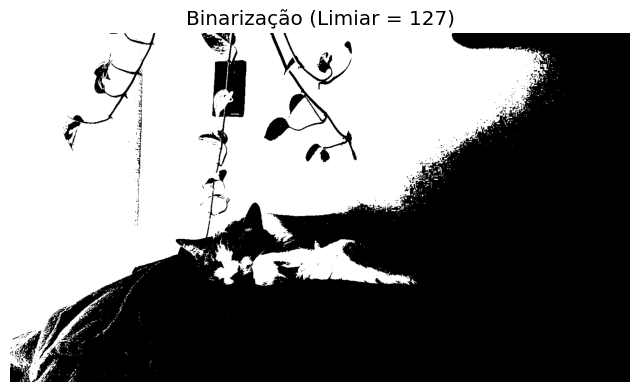

In [20]:
# Aplica o limiar: pixels com intensidade acima de 127 viram 255 (branco); os restantes viram 0 (preto)
# O '_' descarta o primeiro valor retornado pela função (o próprio limiar), guardando apenas a imagem
_, binaria = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Plotagem da imagem binarizada
plt.imshow(binaria, cmap='gray', vmin=0, vmax=255)
plt.title('Binarização (Limiar = 127)')
plt.axis('off')
plt.show()

A binarização com um limiar fixo (como 127) é simples, mas raramente eficaz em fotos do mundo real. Como a iluminação da cena é irregular (mais forte perto da janela), o corte engessado no valor 127 transformou as áreas de sombra na parede e o cobertor em uma massa preta uniforme, ocultando os detalhes do gato. Isso evidencia que utilizar um valor médio não é a melhor estratégia.

### O impacto do valor de limiar

O valor de 127 não é uma regra. Ao alterar o limiar, decidimos o quão clara uma região precisa ser para "sobreviver" na imagem final. Limiares baixos recuperam informações nas sombras, enquanto limiares altos isolam apenas os pontos de luz mais intensos.

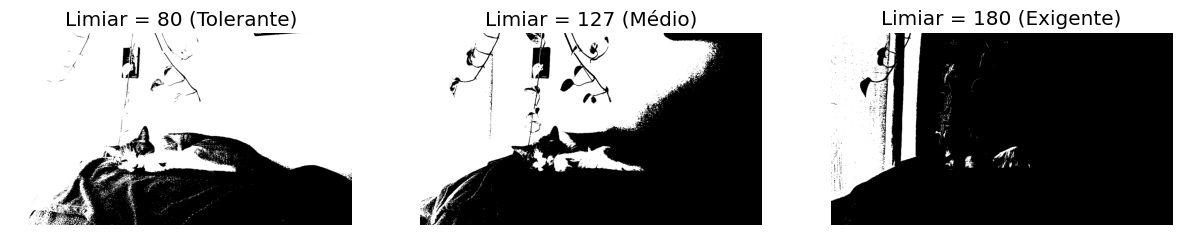

In [21]:
# Cria três binarizações com níveis de exigência diferentes
_, bin_baixa = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY)
_, bin_media = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
_, bin_alta = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(bin_baixa, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Limiar = 80 (Tolerante)')
axes[0].axis('off')

axes[1].imshow(bin_media, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Limiar = 127 (Médio)')
axes[1].axis('off')

axes[2].imshow(bin_alta, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Limiar = 180 (Exigente)')
axes[2].axis('off')

plt.show()

### O Desafio do limiar global (Binarização manual)

A binarização com um limiar fixo é simples, mas raramente eficaz em fotos do mundo real com iluminação irregular. O valor escolhido dita o quão clara uma região precisa ser para "sobreviver" na imagem final. 

Como visto no resultado gerado acima, a escolha manual de um único valor impõe um forte sacrifício de informações (um *trade-off*): ao tentar preservar os detalhes de uma área, inevitavelmente perdemos os de outra.

* **Limiar = 80 (Tolerante):** Ao abaixar a régua, recuperamos os detalhes nas sombras, como a textura do cobertor e o rosto do gato. O revés é que a parede inteira "estoura" e vira um grande bloco branco, fundindo-se com a luz da janela.

* **Limiar = 127 (Médio):** O meio-termo matemático. A parede ganha contorno, mas o cobertor e parte do gato já são engolidos pela sombra.

* **Limiar = 180 (Exigente):** Ao subir muito a régua, quase nada sobrevive. O cobertor e o gato somem na escuridão, restando apenas os reflexos mais intensos de luz.

**Conclusão:** Chutar um limiar global em uma imagem com luz direcional (forte na esquerda e sombra na direita) sempre destruirá alguma parte importante da cena. Para resolver isso de forma inteligente, a Visão Computacional exige abordagens que não dependam de palpites arbitrários, como o cálculo estatístico (Método de Otsu) ou a análise de blocos locais (Binarização Adaptativa).


---

## Síntese

Nesta etapa, olhamos a imagem por dentro. O histograma resume a distribuição das intensidades e serve como o nosso principal diagnóstico visual e matemático. 

As transformações de intensidade — da simples soma de brilho e ajustes de contraste até técnicas avançadas como a equalização adaptativa (CLAHE) — remapeiam essa distribuição com um único objetivo: revelar informações ocultas.

> **O próximo passo:**
> Fica uma pergunta fundamental para a nossa próxima investigação: *de onde vêm esses valores de intensidade?* A resposta não está no código, mas na formação da imagem em si, no caminho físico que a luz percorre desde o mundo real até se transformar em um pixel na tela.